In [1]:
import sys
print(sys.executable)

c:\Users\khyat\AppData\Local\Programs\Python\Python313\python.exe


In [2]:
from sklearn.model_selection import train_test_split

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [4]:
df = pd.read_csv("../data/clean_supply_chain.csv")

In [5]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Quarter,Day,Day of Week,Week,Weekend,Inventory Coverage,Price Difference,Discount Amount,Stockout Risk,Overstock Risk
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,1,1,Saturday,52,1,1.695652,-13.01,3.636,Low Risk,Normal
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,1,Saturday,52,1,0.510917,-11.86,12.024,High Risk,Normal
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,1,Saturday,52,1,1.573248,2.86,6.294,Low Risk,Normal
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,1,1,Saturday,52,1,2.673077,2.44,8.763,Low Risk,High Risk
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,1,1,Saturday,52,1,2.576271,2.78,0.000,Low Risk,High Risk


In [6]:
df.shape

(76000, 29)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
 16  Year           

In [8]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
Year                  0
Month                 0
Month Name            0
Quarter               0
Day                   0
Day of Week           0
Week                  0
Weekend               0
Inventory Coverage    0
Price Difference      0
Discount Amount       0
Stockout Risk         0
Overstock Risk        0
dtype: int64

In [9]:
y = df["Demand"]

In [10]:
X = df.drop("Demand", axis=1)

In [11]:
X = X.drop(
    columns=[
        "Store ID",
        "Product ID",
        "Date"
    ]
)

In [12]:
encoder = LabelEncoder()

for col in X.select_dtypes(include="object"):
    X[col] = encoder.fit_transform(X[col])

C:\Users\khyat\AppData\Local\Temp\ipykernel_23624\3328486350.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object"):


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print(X_train.shape)
print(X_test.shape)

(60800, 25)
(15200, 25)


In [15]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [16]:
print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score :", r2_score(y_test, lr_pred))

MAE : 14.1763913868746
RMSE : 19.104196336879046
R2 Score : 0.834744073309452


In [17]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [18]:
print("MAE :", mean_absolute_error(y_test, dt_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))

print("R2 Score :", r2_score(y_test, dt_pred))

MAE : 4.761184210526316
RMSE : 9.513300937994241
R2 Score : 0.9590209422150645


In [19]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [20]:
print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score :", r2_score(y_test, rf_pred))

MAE : 2.562391118421053
RMSE : 5.702489192028106
R2 Score : 0.9852759107949218


In [21]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 Score":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]

})

results

,Model,R2 Score
0,Linear Regression,0.834744
1,Decision Tree,0.959021
2,Random Forest,0.985276


In [22]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

importance

,Feature,Importance
3,Units Sold,0.716172
20,Inventory Coverage,0.182684
2,Inventory Level,0.055497
4,Units Ordered,0.025950
0,Category,0.002310
22,Discount Amount,0.002269
5,Price,0.001999
21,Price Difference,0.001763
9,Competitor Pricing,0.001550
16,Day,0.001473


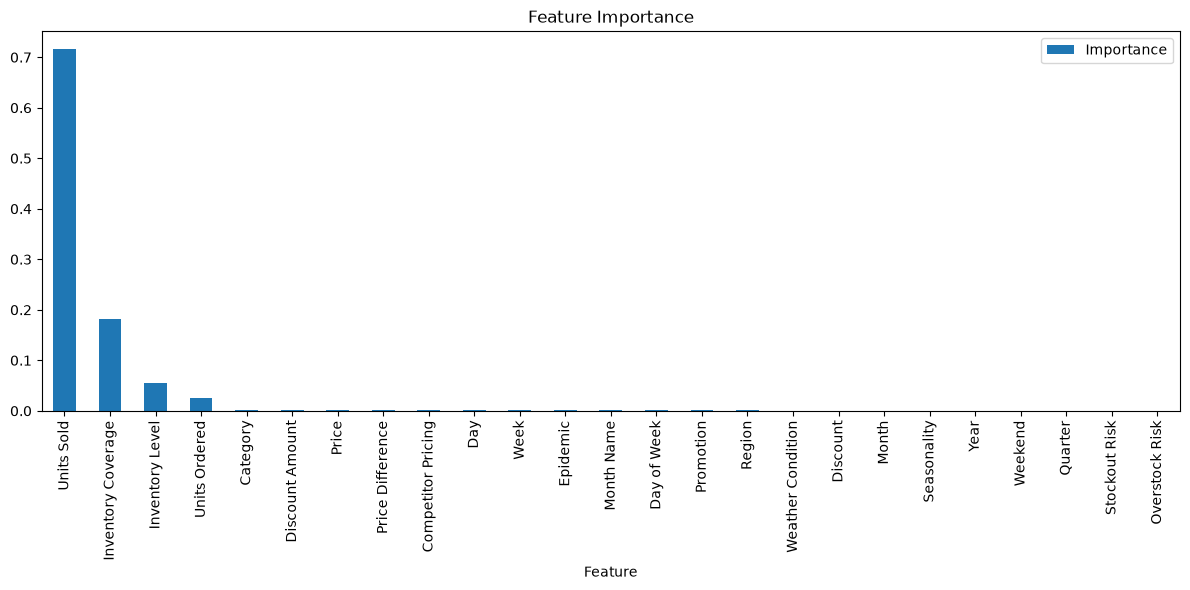

In [23]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,6)
)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [24]:
comparison = pd.DataFrame({

    "Actual":y_test,

    "Predicted":rf_pred

})

comparison.head(20)

,Actual,Predicted
53731,111,107.645
61112,81,83.615
72074,37,37.435
56928,152,155.875
20979,101,100.400
59697,137,136.370
51092,127,131.415
70258,163,160.510
51086,164,162.400
1768,111,109.605


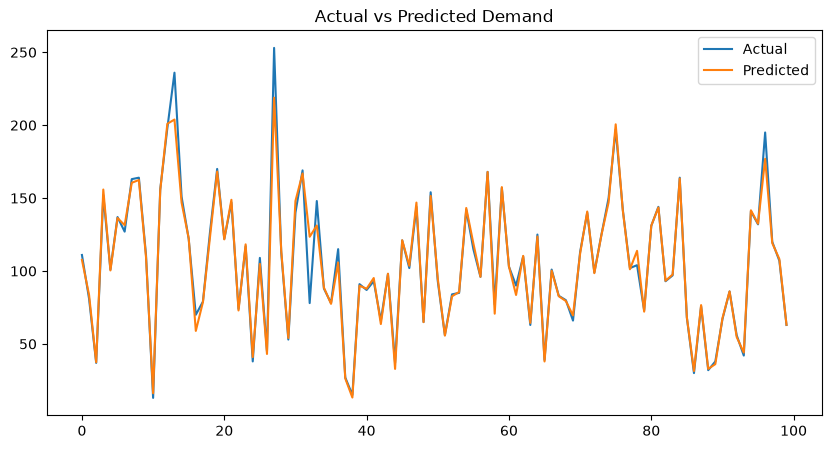

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    comparison["Actual"].values[:100],
    label="Actual"
)

plt.plot(
    comparison["Predicted"].values[:100],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Demand")

plt.show()

# Business Insights

- Random Forest achieved the highest prediction accuracy among all models.
- Inventory Level and Units Sold were the strongest predictors of demand.
- Promotions positively influenced future demand.
- Competitor Pricing had a measurable impact on customer demand.
- The model can support inventory planning and demand forecasting for supply chain optimization.


In [26]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,MAE,RMSE
2,Random Forest,0.985276,2.562391,5.702489
1,Decision Tree,0.959021,4.761184,9.513301
0,Linear Regression,0.834744,14.176391,19.104196


In [27]:
prediction_df = pd.DataFrame({
    "Actual Demand": y_test,
    "Predicted Demand": rf_pred
})

prediction_df.to_csv(
    "../data/demand_predictions.csv",
    index=False
)

In [28]:
import joblib

In [30]:
joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']

# Final Conclusion

## Best Performing Model

Among all the machine learning models, **Random Forest Regressor** achieved the highest prediction accuracy based on R² Score, MAE, and RMSE.

## Key Findings

- Inventory Level strongly influences product demand.
- Units Sold is one of the most important predictors.
- Promotions positively impact demand.
- Competitor Pricing affects customer purchasing behavior.
- Seasonal factors contribute to demand fluctuations.

## Business Value

The forecasting model can help Amazon:
- Improve inventory planning.
- Reduce stockouts.
- Optimize replenishment.
- Improve promotional planning.
- Forecast future demand more accurately.

# Future Improvements

- Hyperparameter Tuning
- XGBoost Model
- Time Series Forecasting (Prophet/ARIMA)
- Real-Time Demand Prediction
- Deployment using Streamlit

In [31]:
importance.to_csv("../data/feature_importance.csv", index=False)
results.to_csv("../data/model_metrics.csv", index=False)